# THREADS Pipeline - Main Runner

Executes all 5 notebooks in order and displays a final results summary.

| Notebook | Purpose |
|---|---|
| 01 | Data exploration & quality verification (PathMNIST) |
| 02 | Preprocessing: MIL bags + real TCGA RNA-seq download |
| 03 | Phikon feature extraction + model training (WSI / Mol / Multi-modal) |
| 04 | Full evaluation: ROC, PR curves, confusion matrices |
| 05 | Advanced analyses: attention heatmaps, gene importance, dropout resilience |

> **Note:** Notebooks 02 and 03 are slow on first run (GDC download + Phikon embedding).
> Subsequent runs load from `artifacts/` cache and are fast.

---

In [1]:
!pip install nbconvert jupyter

In [2]:
import subprocess, sys, os, time

NOTEBOOKS = [
    "01_data_exploration_and_verification.ipynb",
    "02_preprocessing_new.ipynb",
    "03_feature_extraction_and_training.ipynb",
    "04_evaluation.ipynb",
    "05_new_analysis.ipynb",
]

def run_notebook(path):
    """Execute a notebook in-place, overwriting its outputs."""
    t0 = time.time()
    print(f"\n{'='*60}")
    print(f"Running: {path}")
    print(f"{'='*60}")
    result = subprocess.run(
        [sys.executable, "-m", "nbconvert",
         "--to", "notebook",
         "--execute",
         "--inplace",
         "--ExecutePreprocessor.timeout=3600",
         "--ExecutePreprocessor.kernel_name=python3",
         path],
        capture_output=True, text=True
    )
    elapsed = time.time() - t0
    if result.returncode == 0:
        print(f"  DONE in {elapsed/60:.1f} min")
    else:
        print(f"  FAILED after {elapsed/60:.1f} min")
        print(result.stderr[-2000:])   # last 2000 chars of error
        raise RuntimeError(f"{path} failed -- see error above")
    return elapsed

times = {}
for nb in NOTEBOOKS:
    times[nb] = run_notebook(nb)

print("\n" + "="*60)
print("All notebooks completed.")
print("="*60)
for nb, t in times.items():
    print(f"  {nb:<50s}  {t/60:.1f} min")


Running: 01_data_exploration_and_verification.ipynb


  DONE in 0.3 min

Running: 02_preprocessing_new.ipynb


  DONE in 0.6 min

Running: 03_feature_extraction_and_training.ipynb


  DONE in 4.9 min

Running: 04_evaluation.ipynb


  DONE in 0.2 min

Running: 05_new_analysis.ipynb


  DONE in 0.2 min

All notebooks completed.
  01_data_exploration_and_verification.ipynb          0.3 min
  02_preprocessing_new.ipynb                          0.6 min
  03_feature_extraction_and_training.ipynb            4.9 min
  04_evaluation.ipynb                                 0.2 min
  05_new_analysis.ipynb                               0.2 min


---
## Final Results Summary

Loaded from `artifacts/results.pkl` saved by notebook 03.

Model                              AUC   Avg-P       Acc      Prec       Rec
WSI Only (Dual-ABMIL)           0.8356  0.8727    78.33%    90.48%    63.33%
Molecular Only (MLP)            1.0000  1.0000   100.00%   100.00%   100.00%
Multi-Modal THREADS             1.0000  1.0000   100.00%   100.00%   100.00%


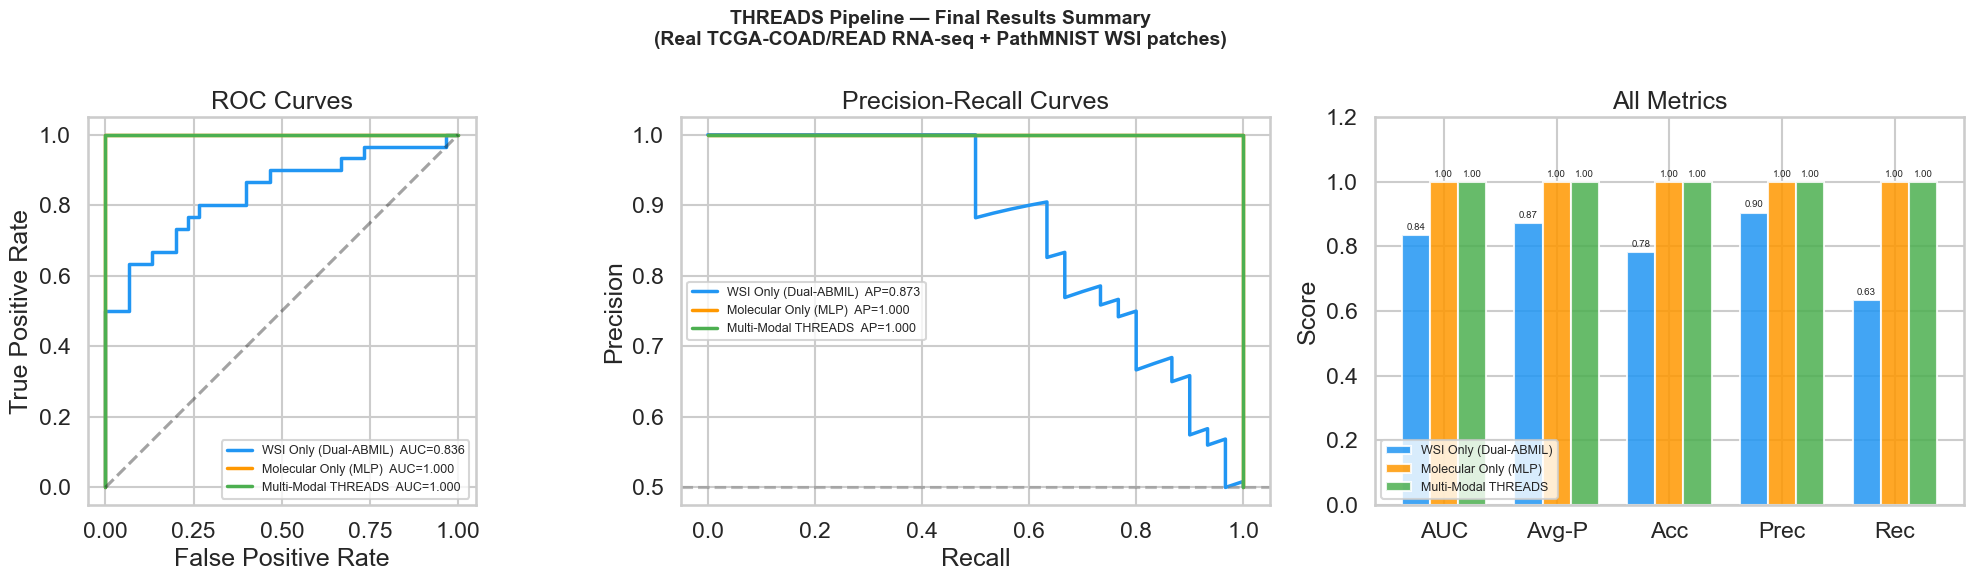

Pipeline complete.


In [3]:
import pickle, os, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_curve, confusion_matrix

sns.set_theme(style='whitegrid', context='talk')
ARTIFACTS_DIR = "artifacts"

with open(os.path.join(ARTIFACTS_DIR, "results.pkl"), "rb") as f:
    res = pickle.load(f)

with open(os.path.join(ARTIFACTS_DIR, "preprocessing.pkl"), "rb") as f:
    prep = pickle.load(f)

results_wsi = res["results_wsi"]
results_mol = res["results_mol"]
results_mm  = res["results_mm"]
cancer_genes = prep["cancer_genes"]

models_results = {
    "WSI Only (Dual-ABMIL)"   : results_wsi,
    "Molecular Only (MLP)"    : results_mol,
    "Multi-Modal THREADS"     : results_mm,
}
palette = {
    "WSI Only (Dual-ABMIL)"   : "#2196F3",
    "Molecular Only (MLP)"    : "#FF9800",
    "Multi-Modal THREADS"     : "#4CAF50",
}

# ── Metrics table ─────────────────────────────────────────────────────────────
print(f"{'='*75}")
print(f"{'Model':<30} {'AUC':>7} {'Avg-P':>7} {'Acc':>9} {'Prec':>9} {'Rec':>9}")
print(f"{'='*75}")
for name, r in models_results.items():
    print(f"{name:<30} {r['auc']:>7.4f} {r['ap']:>7.4f}"
          f" {r['acc']*100:>8.2f}% {r['precision']*100:>8.2f}% {r['recall']*100:>8.2f}%")
print(f"{'='*75}")

# ── Plot: ROC + PR + bar ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle("THREADS Pipeline — Final Results Summary\n"
             "(Real TCGA-COAD/READ RNA-seq + PathMNIST WSI patches)",
             fontsize=14, fontweight='bold')

# ROC
ax = axes[0]
for name, r in models_results.items():
    ax.plot(r['fpr'], r['tpr'], color=palette[name], lw=2.5,
            label=f"{name}  AUC={r['auc']:.3f}")
ax.plot([0,1],[0,1],'k--',alpha=0.4)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves")
ax.legend(fontsize=9)
ax.set_aspect('equal')

# PR
ax = axes[1]
for name, r in models_results.items():
    p, rc, _ = precision_recall_curve(r['labels'], r['preds'])
    ax.plot(rc, p, color=palette[name], lw=2.5,
            label=f"{name}  AP={r['ap']:.3f}")
ax.axhline(0.5, color='gray', ls='--', alpha=0.5)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curves")
ax.legend(fontsize=9)

# Bar chart
ax = axes[2]
keys  = ["auc", "ap", "acc", "precision", "recall"]
xlbls = ["AUC", "Avg-P", "Acc", "Prec", "Rec"]
x, w  = np.arange(len(keys)), 0.25
for i, (name, r) in enumerate(models_results.items()):
    vals = [r[k] for k in keys]
    bars = ax.bar(x + i*w, vals, w, label=name, color=palette[name], alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f"{v:.2f}", ha='center', va='bottom', fontsize=7)
ax.set_xticks(x+w); ax.set_xticklabels(xlbls)
ax.set_ylim(0, 1.2); ax.set_ylabel("Score")
ax.set_title("All Metrics")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()
print("Pipeline complete.")